# Reproduce Figure 5
This script performs PCA analysis on the collected data from layer 22 to visualize the variance explained by the principal components.
This layer is observed to be the creation layer for many secondary attention sinks in deepseek-14b, making it a key focus for understanding the underlying mechanisms of these sinks in the model.
You will need the following file:
- `layer_22_path`: ./results/example/creation_layer_info_dict_deepseek-14b_n_{n_gen}_other_22.pt

In [1]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import os 

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    device_map="auto",
    attn_implementation="sdpa",
    cache_dir="/data/models", 
)
model.eval()

/home/thw20/.conda/envs/sink/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 4/4 [00:05<00:00,  1.26s/it]


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(152064, 5120)
    (layers): ModuleList(
      (0-47): 48 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=5120, out_features=5120, bias=True)
          (k_proj): Linear(in_features=5120, out_features=1024, bias=True)
          (v_proj): Linear(in_features=5120, out_features=1024, bias=True)
          (o_proj): Linear(in_features=5120, out_features=5120, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=5120, out_features=13824, bias=False)
          (up_proj): Linear(in_features=5120, out_features=13824, bias=False)
          (down_proj): Linear(in_features=13824, out_features=5120, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((5120,), eps=1e-05)
        (post_attention_layernorm): Qwen2RMSNorm((5120,), eps=1e-05)
      )
    )
    (norm): Qwen2RMSNorm((5120,), eps=1e-05)
    (

In [8]:
import torch
import torch.nn.functional as F
from pathlib import Path
n_gen = 10
layer_22_path = Path(f'./results/example/creation_layer_info_dict_deepseek-14b_n_{n_gen}_other_22.pt')
save_dict = torch.load(layer_22_path, map_location='cpu')

torch.Size([251, 5120]) torch.Size([109078, 5120])
MLP(pc1): Norm Pos: 8.8082, Cosine with BOS down Pos: 0.9921 | Norm Neg: 1.1088, Cosine with BOS down Neg: 0.9962
MLP(pc2): Norm Pos: 2.7750, Cosine with BOS down Pos: 0.9954 | Norm Neg: 1.8383, Cosine with BOS down Neg: 0.9950
MLP(pc3): Norm Pos: 1.2641, Cosine with BOS down Pos: -0.9899 | Norm Neg: 11.0701, Cosine with BOS down Neg: -0.9943
MLP(pc4): Norm Pos: 2.8837, Cosine with BOS down Pos: -0.9936 | Norm Neg: 1.4109, Cosine with BOS down Neg: -0.9915
MLP(pc5): Norm Pos: 1.3361, Cosine with BOS down Pos: -0.9900 | Norm Neg: 4.5203, Cosine with BOS down Neg: -0.9919
MLP(pc6): Norm Pos: 1.2508, Cosine with BOS down Pos: -0.9954 | Norm Neg: 0.5734, Cosine with BOS down Neg: -0.9928
MLP(pc7): Norm Pos: 0.1307, Cosine with BOS down Pos: -0.6028 | Norm Neg: 0.1281, Cosine with BOS down Neg: -0.5546
MLP(pc8): Norm Pos: 0.2927, Cosine with BOS down Pos: -0.9701 | Norm Neg: 0.3865, Cosine with BOS down Neg: -0.9783
MLP(pc9): Norm Pos: 0.06

/tmp/ipykernel_1511869/2743278977.py:193: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mlp_pc = torch.tensor(


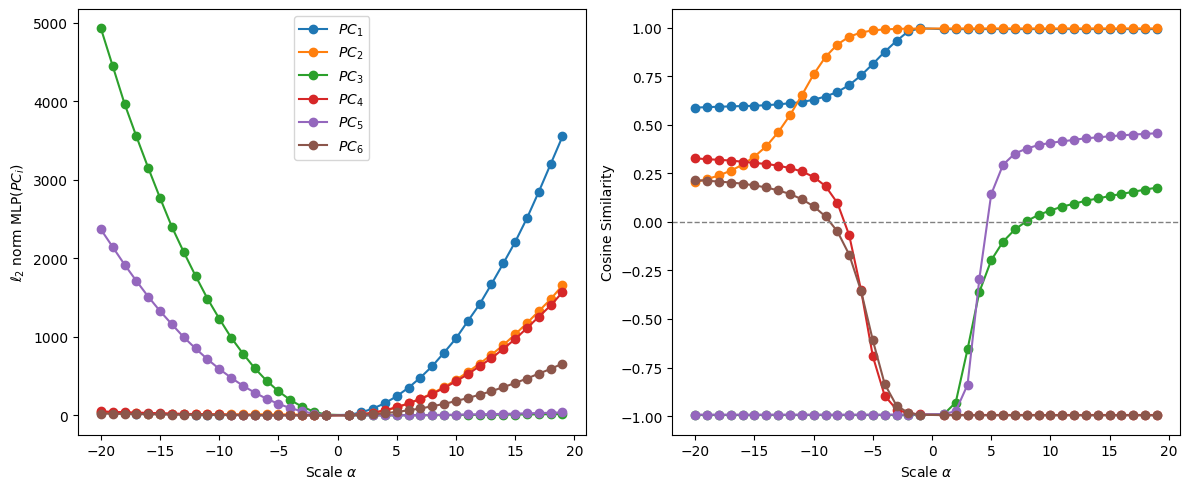

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ===============================
# 1) Load cliff / other features
# ===============================
mlp_input_list = save_dict['cliff']['mlp_input'].to(torch.float32)
attn_output_list = save_dict['cliff']['attn_output'].to(torch.float32)
residual_list = save_dict['cliff']['residual'].to(torch.float32)

other_mlp_input_list = save_dict['other']['mlp_input'].to(torch.float32)
other_attn_output_list = save_dict['other']['attn_output'].to(torch.float32)
other_residual_list = save_dict['other']['residual'].to(torch.float32)

print(mlp_input_list.shape, other_mlp_input_list.shape)

# =====================================
# 2) Match sample counts (cliff vs other)
# =====================================
torch.manual_seed(42)
other_sample_num = mlp_input_list.size(0)

sample_other_mlp_input_list = other_mlp_input_list[
    torch.randperm(other_mlp_input_list.size(0))[:other_sample_num]
]
sample_other_attn_output_list = other_attn_output_list[
    torch.randperm(other_attn_output_list.size(0))[:other_sample_num]
]
sample_other_residual_list = other_residual_list[
    torch.randperm(other_residual_list.size(0))[:other_sample_num]
]

mask = torch.cat(
    (
        torch.ones(mlp_input_list.shape[0], dtype=torch.bool),
        torch.zeros(sample_other_mlp_input_list.shape[0], dtype=torch.bool),
    )
)

# =================================
# 3) Build concatenated state tensors
# =================================
plot_list = ['attn_output', 'residual', 'mlp_input']

total_attn = torch.cat((attn_output_list, sample_other_attn_output_list), dim=0)
total_residual = torch.cat((residual_list, sample_other_residual_list), dim=0)
total_mlp = torch.cat((mlp_input_list, sample_other_mlp_input_list), dim=0)

use_centering = True
if use_centering:
    total_attn -= total_attn.mean(dim=0, keepdim=True)
    total_residual -= total_residual.mean(dim=0, keepdim=True)
    total_mlp -= total_mlp.mean(dim=0, keepdim=True)

# =======================================================
# 4) Fit KMeans + PCA per state and keep the final `pca`
# =======================================================
for state_name in plot_list:
    if state_name == 'mlp_input':
        x = total_mlp
    elif state_name == 'attn_output':
        x = total_attn
    elif state_name == 'residual':
        x = total_residual
    else:
        continue

    x_np = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
    num_component = x_np.shape[0]

    # KMeans (kept for consistency with original pipeline)
    n_clusters = 2
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(x_np)

    # PCA
    pca = PCA(n_components=num_component)
    x_pca = pca.fit_transform(x_np)

# =====================================================
# 5) Analyze PCA directions through layer-22 MLP output
# =====================================================
effective_pos_direction, effective_neg_direction = [], []
threshold = 0.98

norm_list_pos = np.zeros(pca.n_components_)
norm_list_neg = np.zeros(pca.n_components_)
cos_list_pos = np.zeros(pca.n_components_)
cos_list_neg = np.zeros(pca.n_components_)

num_components = pca.n_components_
for component_idx in range(num_components):
    pc_vector = torch.tensor(pca.components_[component_idx], device=model.device)

    mlp_pc_pos = model.model.layers[22].mlp(
        pc_vector.to(torch.bfloat16).to(model.device)
    ).detach().float().cpu()
    mlp_pc_neg = model.model.layers[22].mlp(
        (-pc_vector).to(torch.bfloat16).to(model.device)
    ).detach().float().cpu()

    mlp_pc_norm_pos = torch.norm(mlp_pc_pos, p=2)
    mlp_pc_norm_neg = torch.norm(mlp_pc_neg, p=2)

    a_down_pos = torch.nn.functional.cosine_similarity(
        save_dict['bos']['down'].detach().float().cpu(),
        mlp_pc_pos,
        dim=-1,
    ).to(torch.float32).cpu()
    a_down_neg = torch.nn.functional.cosine_similarity(
        save_dict['bos']['down'].detach().float().cpu(),
        mlp_pc_neg,
        dim=-1,
    ).to(torch.float32).cpu()

    if a_down_pos.item() > threshold:
        effective_pos_direction.append(component_idx)
    elif a_down_pos.item() < -threshold:
        effective_neg_direction.append(component_idx)

    if a_down_neg.item() > threshold:
        effective_pos_direction.append(component_idx)
    elif a_down_neg.item() < -threshold:
        effective_neg_direction.append(component_idx)

    norm_list_pos[component_idx] = mlp_pc_norm_pos.item()
    cos_list_pos[component_idx] = a_down_pos.item()
    norm_list_neg[component_idx] = mlp_pc_norm_neg.item()
    cos_list_neg[component_idx] = a_down_neg.item()

    print(
        f"MLP(pc{component_idx + 1}): Norm Pos: {mlp_pc_norm_pos.item():.4f}, "
        f"Cosine with BOS down Pos: {a_down_pos.item():.4f} | "
        f"Norm Neg: {mlp_pc_norm_neg.item():.4f}, "
        f"Cosine with BOS down Neg: {a_down_neg.item():.4f}"
    )

print(
    "Effective directions with cosine similarity > {} or < -{}:".format(
        threshold, threshold
    ),
    len(effective_pos_direction) + len(effective_neg_direction),
    effective_pos_direction + effective_neg_direction,
)

# ===============================
# 6) Report top components by norm
# ===============================
sorted_indices = np.argsort(-norm_list_pos)
print("Top components by norm (positive directions):")
for rank, component_idx in enumerate(sorted_indices[:10], start=1):
    print(
        f"Rank {rank}: PC{component_idx + 1} with Norm {norm_list_pos[component_idx]:.4f} , "
        f"Cosine Similarity with BOS down: {cos_list_pos[component_idx]:.4f}"
    )

sorted_indices = np.argsort(-norm_list_neg)
print("Top components by norm (negative directions):")
for rank, component_idx in enumerate(sorted_indices[:10], start=1):
    print(
        f"Rank {rank}: PC{component_idx + 1} with Norm {norm_list_neg[component_idx]:.4f} , "
        f"Cosine Similarity with BOS down: {cos_list_neg[component_idx]:.4f}"
    )

# ===========================================
# 7) Analyze scaling behavior of top PC range
# ===========================================
mlp_pc_pos = model.model.layers[22].mlp(
    torch.tensor(
        10 * pca.components_[0] + 10 * pca.components_[1],
        device=model.device,
    ).to(torch.bfloat16).to(model.device)
).detach().float().cpu()

a_down_pos = torch.nn.functional.cosine_similarity(
    save_dict['bos']['down'].detach().float().cpu(),
    mlp_pc_pos,
    dim=-1,
).to(torch.float32).cpu()

from collections import defaultdict

pc_map = defaultdict(list)
pc_range = range(0, 6)

for scale in range(-20, 20):
    if scale == 0:
        continue

    for pc in pc_range:
        mlp_pc = torch.tensor(
            model.model.layers[22].mlp(
                torch.tensor(scale * pca.components_[pc], device=model.device)
                .to(torch.bfloat16)
                .to(model.device)
            )
        )
        cos_sim = torch.nn.functional.cosine_similarity(
            mlp_pc.detach().float().cpu(),
            save_dict['bos']['down'].detach().float().cpu(),
            dim=-1,
        ).to(torch.float32).cpu()

        pc_map[pc].append((scale, torch.norm(mlp_pc).item(), cos_sim.item()))

# ===============================
# 8) Plot norm / cosine vs scale
# ===============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for pc in pc_range:
    scale_list = [item[0] for item in pc_map[pc]]
    norm_list = [item[1] for item in pc_map[pc]]
    plt.plot(scale_list, norm_list, marker='o', label=fr'$PC_{pc+1}$')
plt.xlabel(r'Scale $\alpha$')
plt.ylabel(r'$\ell_2 \text{ norm } \text{MLP}(PC_i)$')
plt.legend()

plt.subplot(1, 2, 2)
for pc in pc_range:
    scale_list = [item[0] for item in pc_map[pc]]
    direction_list = [item[2] for item in pc_map[pc]]
    plt.plot(scale_list, direction_list, marker='o', label=fr'$PC_{pc+1}$')
plt.xlabel(r'Scale $\alpha$')
plt.ylabel(r'Cosine Similarity')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
save_path = layer_22_path.parent / f'mlp_pc_analysis_n_{n_gen}_other_22.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved grid plot to: {save_path}")


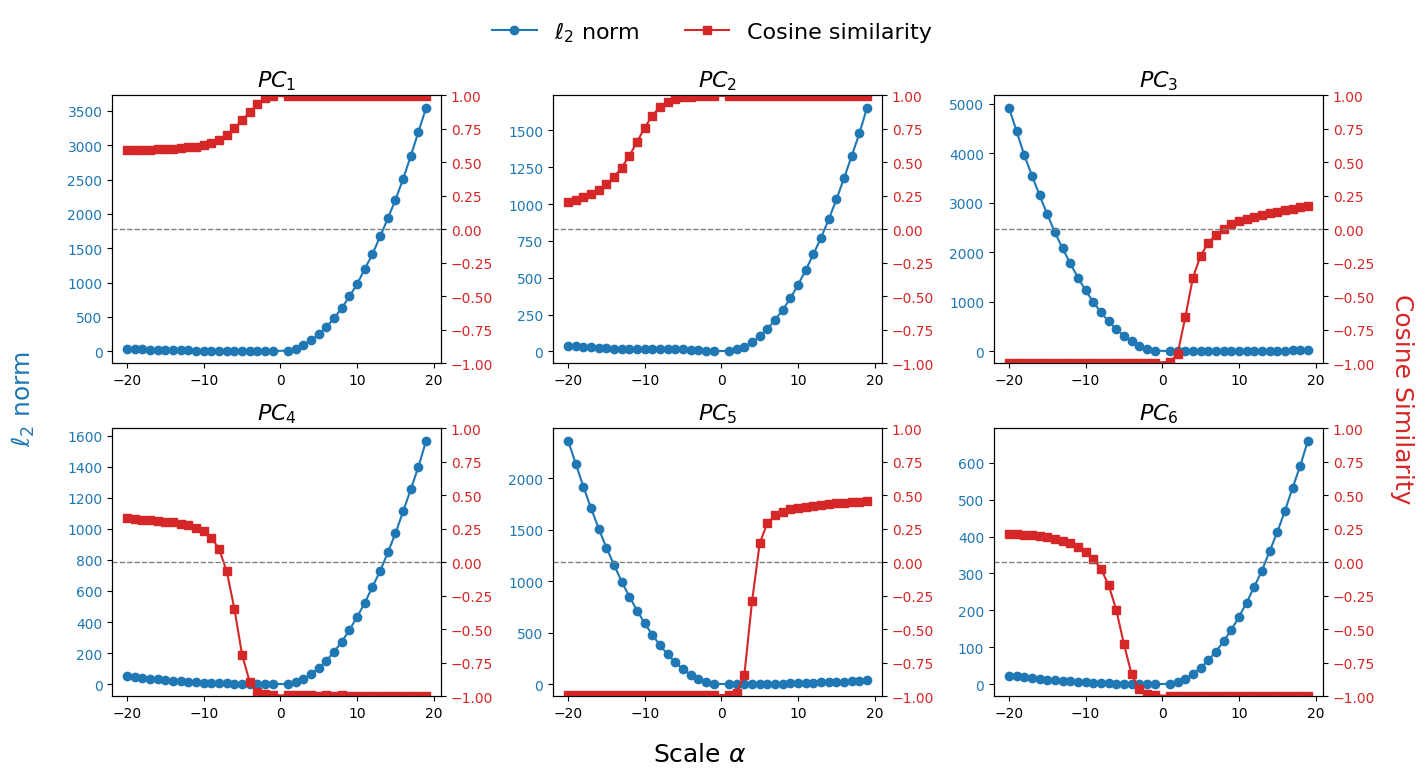

In [ ]:
fig, axes = plt.subplots(
    2, 3,                    # <-- 2 by 3 layout
    figsize=(15, 8),
)

axes = axes.flatten()        # flatten 2×3 into 1D list for easy indexing

for idx, pc in enumerate(pc_range):
    ax1 = axes[idx]

    scale_list     = [item[0] for item in pc_map[pc]]
    norm_list      = [item[1] for item in pc_map[pc]]
    direction_list = [item[2] for item in pc_map[pc]]

    # Left axis: L2 norm
    l1, = ax1.plot(scale_list, norm_list, marker='o', color='tab:blue', label=r'$\ell_2$ norm')
    # ax1.set_ylabel(r'$\ell_2$ norm', color='tab:blue', fontsize=16)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Right axis: cosine similarity (shared range)
    ax2 = ax1.twinx()
    l2, = ax2.plot(scale_list, direction_list, marker='s', color='tab:red', label='Cosine similarity')
    # ax2.set_ylabel('Cosine Similarity', color='tab:red', fontsize=16)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Shared right y-axis
    ax2.set_ylim(-1, 1)

    # horizontal line at 0
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1)

    # x-label and title
    # ax1.set_xlabel(r'Scale $\alpha$', fontsize=16)
    ax1.set_title(fr'$PC_{pc+1}$', fontsize=16)
    # ax1.legend(handles=[l1, l2], loc='best')


# Shared left y-label
fig.supylabel(
    r'$\ell_2$ norm',
    fontsize=18,
    x=0.04,          # move closer/farther from plots
    color='tab:blue'
)

# Shared right y-label
fig.text(
    0.96, 0.5,      # (x, y) in figure coordinates
    'Cosine Similarity',
    va='center',
    rotation=-90,
    fontsize=18,
    color='tab:red'
)

fig.legend(
    handles=[l1, l2],
    loc='upper center',
    ncol=2,
    frameon=False,
    fontsize=16,
)

fig.supxlabel(
    r'Scale $\alpha$',
    fontsize=18,
    y=0.04        # adjust vertical position
)
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.tight_layout()
# plt.tight_layout(rect=[0.05, 0, 0.95, 0.93])
plt.tight_layout(rect=[0.04, 0.03, 0.96, 0.93])
save_path = layer_22_path.parent / 'pc_mlp_overlay_grid.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved grid plot to: {save_path}")


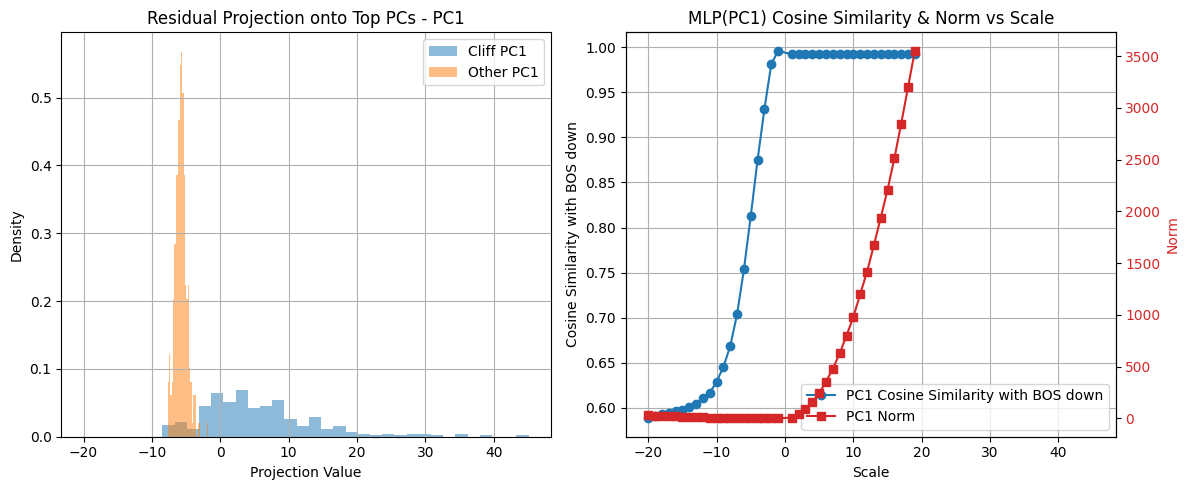

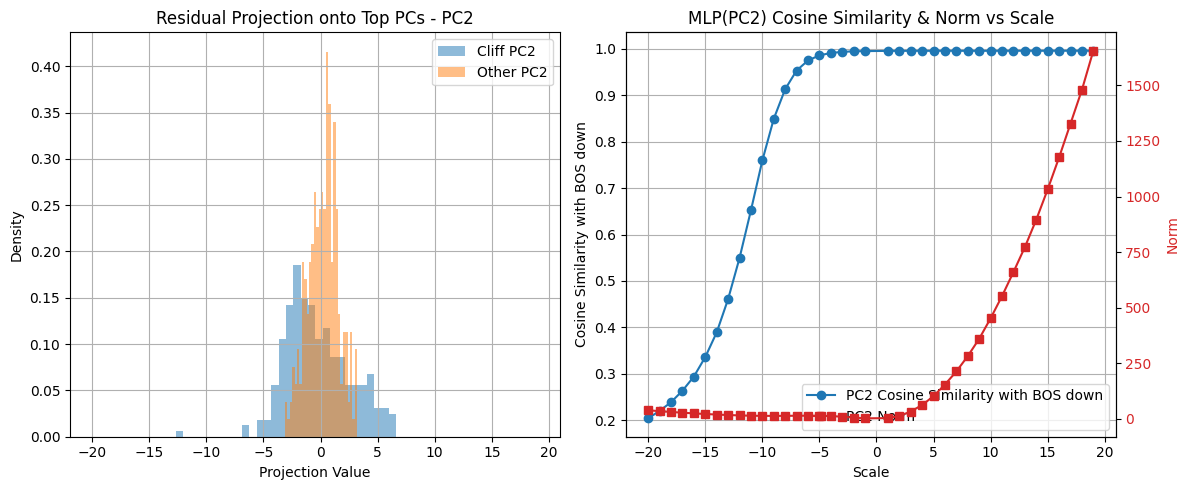

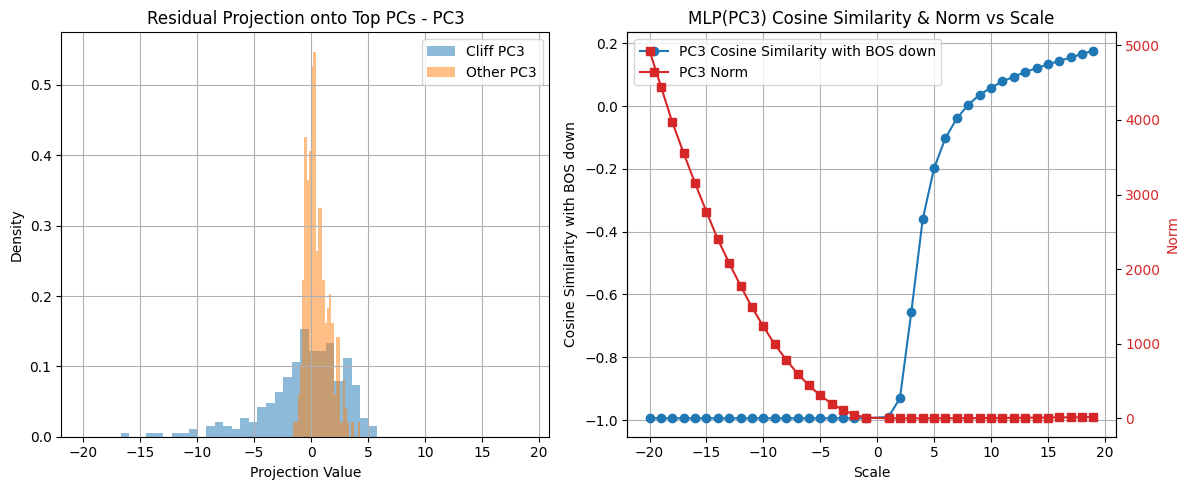

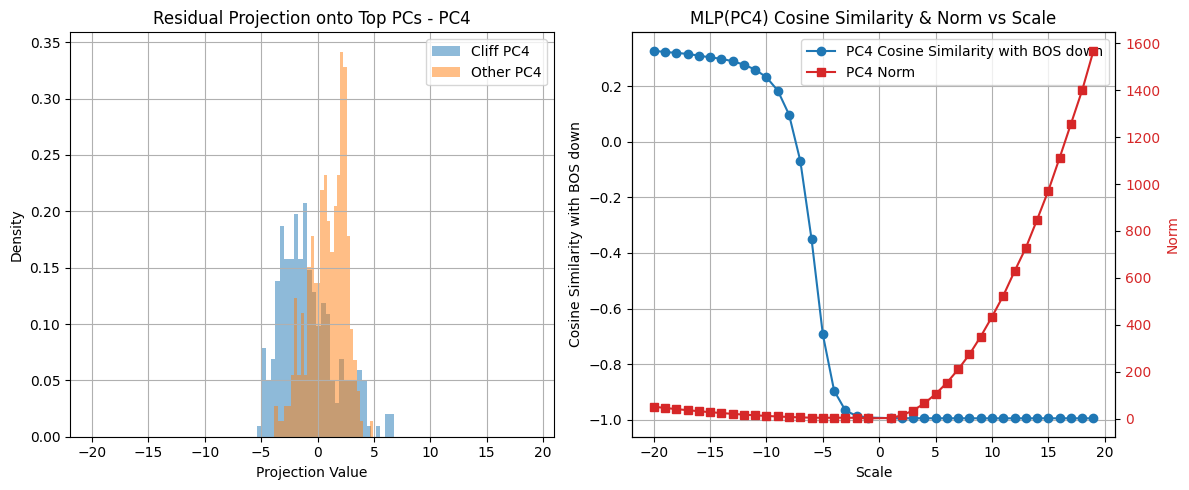

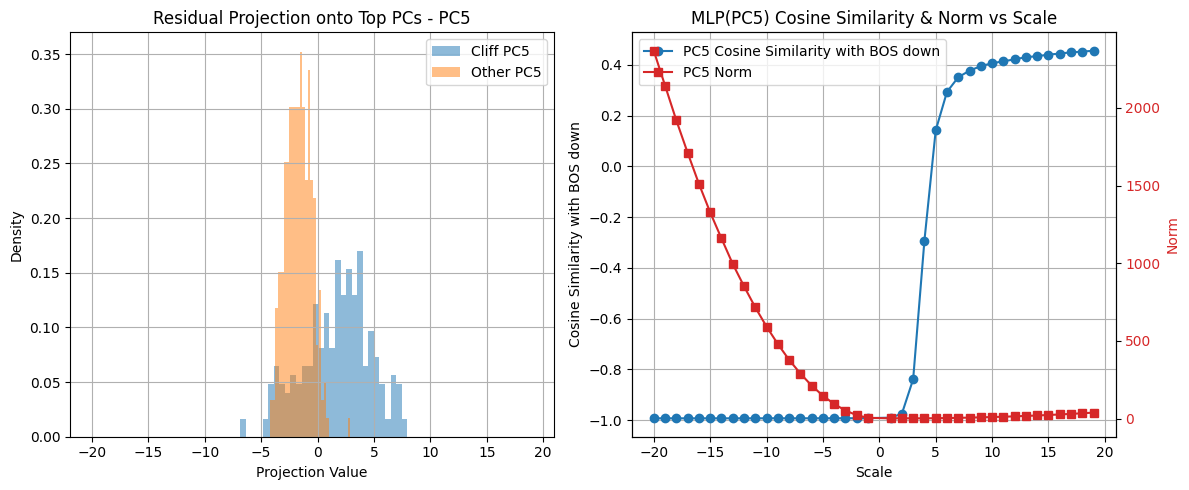

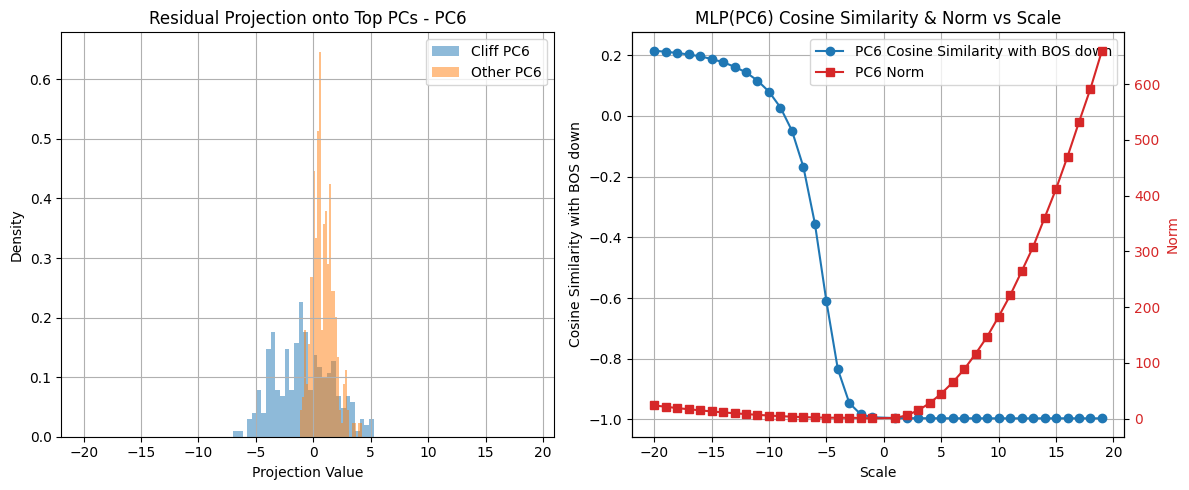

In [ ]:
# use the top 6 pcs to analyze the residual directions
top_pcs = [0, 1, 2, 3, 4, 5]

total_residual_top_pcs = total_residual @ torch.tensor(pca.components_[top_pcs].T, device=total_residual.device)
for i, pc_idx in enumerate(top_pcs):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    # --- Left subplot ---
    axes[0].hist(
        total_residual_top_pcs[mask == 1, i].cpu().numpy(),
        bins=30, alpha=0.5, label=f'Cliff PC{pc_idx+1}', density=True
    )
    axes[0].hist(
        total_residual_top_pcs[mask == 0, i].cpu().numpy(),
        bins=30, alpha=0.5, label=f'Other PC{pc_idx+1}', density=True
    )
    axes[0].set_title(f'Residual Projection onto Top PCs - PC{pc_idx+1}')
    axes[0].set_xlabel('Projection Value')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    axes[0].grid(True)

    # --- Right subplot ---
    scale_list = [item[0] for item in pc_map[pc_idx]]
    norm_list = [item[1] for item in pc_map[pc_idx]]
    direction_list = [item[2] for item in pc_map[pc_idx]]
    axes[1].plot(scale_list, direction_list, marker='o',
                label=f'PC{pc_idx+1} Cosine Similarity with BOS down')

    axes[1].set_title(f'MLP(PC{pc_idx+1}) Cosine Similarity with BOS down vs Scale')
    axes[1].set_xlabel('Scale')
    axes[1].set_ylabel('Cosine Similarity with BOS down')
    axes[1].legend()
    axes[1].grid(True)
    ax2 = axes[1].twinx()
    ax2.plot(scale_list, norm_list, marker='s', color='tab:red',
            label=f'PC{pc_idx+1} Norm')
    ax2.set_ylabel('Norm', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Combine legends from both axes
    lines, labels = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines + lines2, labels + labels2, loc='best')

    axes[1].set_title(f'MLP(PC{pc_idx+1}) Cosine Similarity & Norm vs Scale')

    plt.tight_layout()
    plt.show()
    plt.close()

/tmp/ipykernel_667266/1529101322.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mlp_pc = torch.tensor(model.model.layers[22].mlp(torch.tensor(scale * pca.components_[pc_idx], device=model.device).to(torch.bfloat16).to(model.device)))


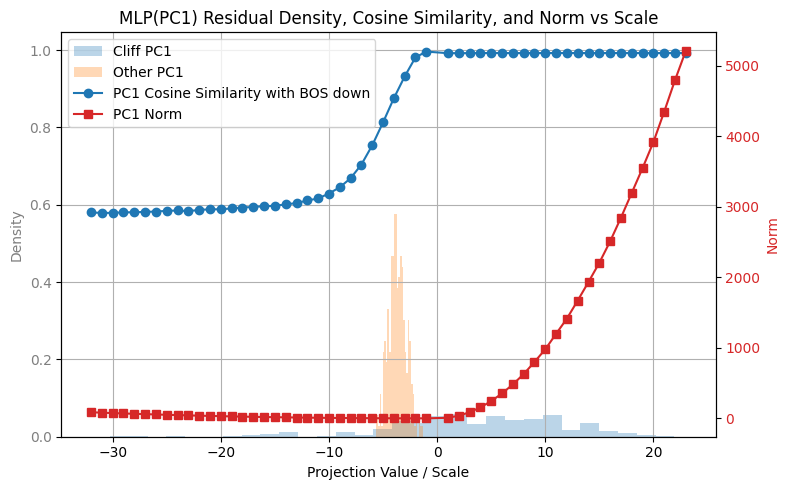

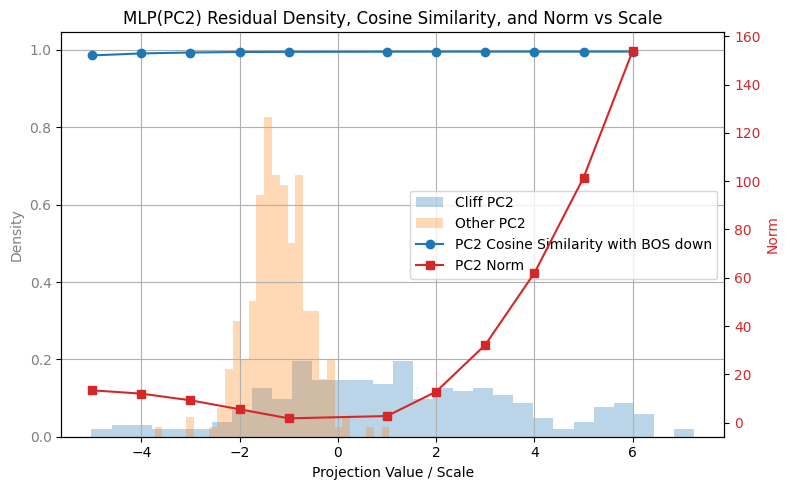

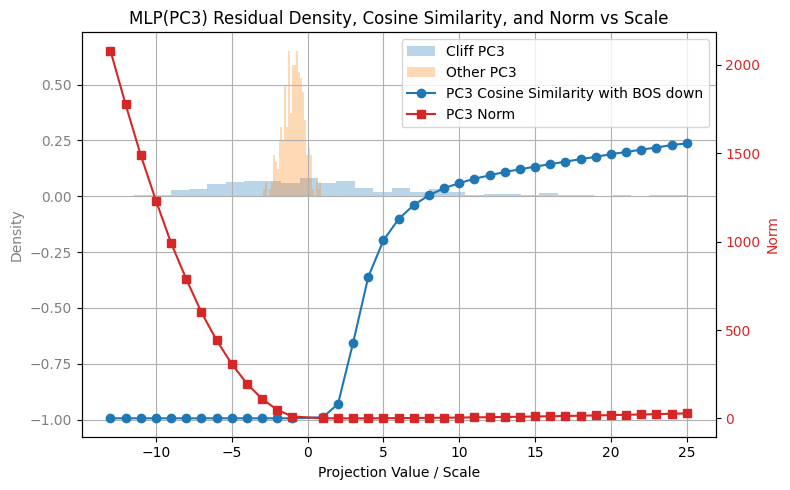

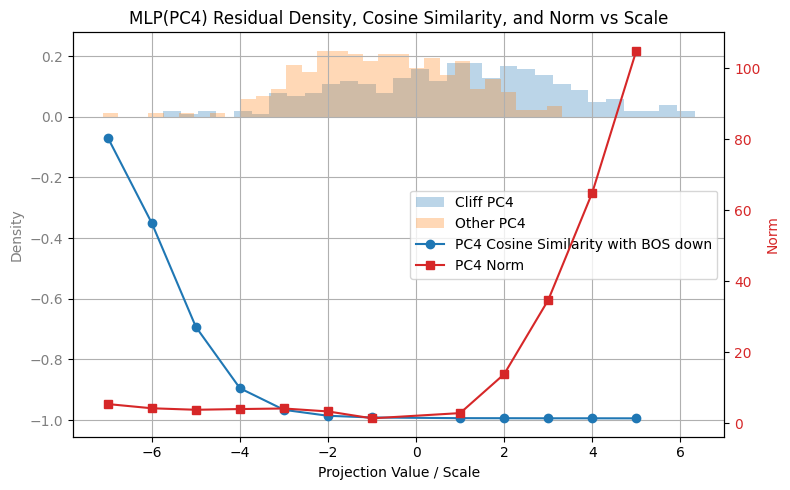

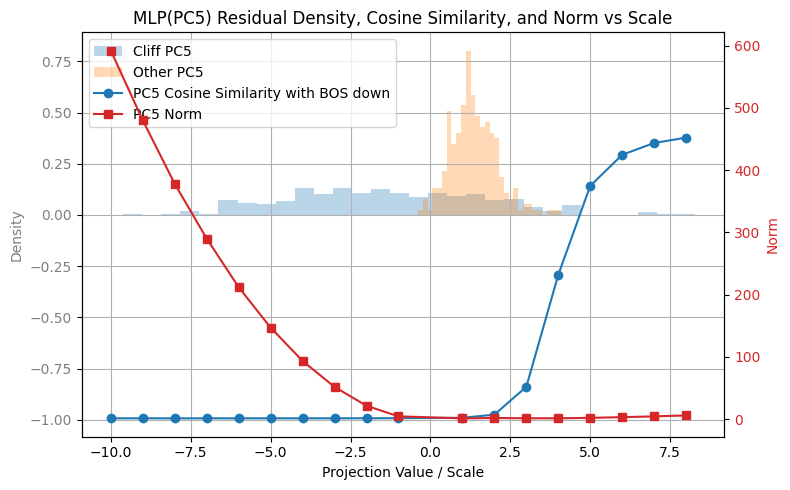

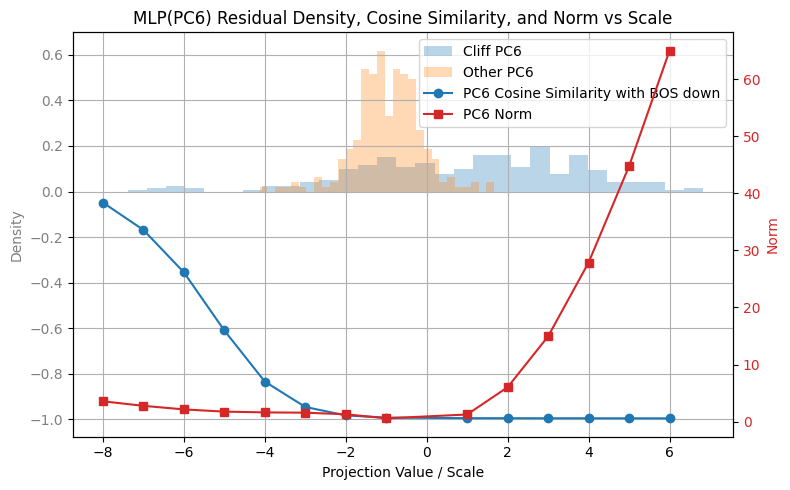

In [34]:

top_pcs = [0, 1, 2, 3, 4, 5]
from collections import defaultdict
pc_map = defaultdict(list)
        

x = total_attn

total_top_pcs = x @ torch.tensor(pca.components_[top_pcs].T, device=x.device)
for i, pc_idx in enumerate(top_pcs):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    
    # --- Histogram (density) overlay ---
    data_cliff = total_top_pcs[mask == 1, i].cpu().numpy()
    data_other = total_top_pcs[mask == 0, i].cpu().numpy()

    ax1.hist(
        data_cliff,
        bins=30, alpha=0.3, label=f'Cliff PC{pc_idx+1}', density=True, color='tab:blue'
    )
    ax1.hist(
        data_other,
        bins=30, alpha=0.3, label=f'Other PC{pc_idx+1}', density=True, color='tab:orange'
    )
    ax1.set_xlabel('Projection Value / Scale')
    ax1.set_ylabel('Density', color='tab:gray')
    ax1.tick_params(axis='y', labelcolor='tab:gray')

    # --- Cosine similarity curve on left y-axis (secondary plot) ---
    scale_range = range(int(ax1.get_xlim()[0]), int(ax1.get_xlim()[1]))
    for scale in scale_range:
        if scale == 0:
            continue
        mlp_pc = torch.tensor(model.model.layers[22].mlp(torch.tensor(scale * pca.components_[pc_idx], device=model.device).to(torch.bfloat16).to(model.device)))
        cos_sim = torch.nn.functional.cosine_similarity(
                mlp_pc.detach().float().cpu(),
                save_dict['bos']['down'].detach().float().cpu(),
                dim=-1
            ).to(torch.float32).cpu()
        pc_map[pc_idx].append((scale, torch.norm(mlp_pc).item(), cos_sim.item()))

    scale_list = [item[0] for item in pc_map[pc_idx]]
    norm_list = [item[1] for item in pc_map[pc_idx]]
    direction_list = [item[2] for item in pc_map[pc_idx]]

    ax1.plot(scale_list, direction_list, marker='o', color='tab:blue',
            label=f'PC{pc_idx+1} Cosine Similarity with BOS down')
    ax1.grid(True)

    # --- Norm on right y-axis ---
    ax2 = ax1.twinx()
    ax2.plot(scale_list, norm_list, marker='s', color='tab:red',
            label=f'PC{pc_idx+1} Norm')
    ax2.set_ylabel('Norm', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # --- Title and legend ---
    ax1.set_title(f'MLP(PC{pc_idx+1}) Residual Density, Cosine Similarity, and Norm vs Scale')

    # Combine legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='best')

    plt.tight_layout()
    plt.show()
    plt.close()